In [1]:
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
def load_data():
    df_merged = pd.read_csv('merged_data.csv')
    df_oa = pd.read_csv('openalex_ai_vietnam.csv')
    return df_merged, df_oa

df_merged, df_oa = load_data()

In [3]:
def clean_merged_data(df):
    df['Acceptance_Rate'] = df['Acceptance_Rate'].fillna(df['Acceptance_Rate'].median())
    df['Enrollment'] = df['Enrollment'].fillna(df['Enrollment'].median())
    df['AI_Publications'] = df['AI_Publications'].fillna(0)
    df['AI_Citations'] = df['AI_Citations'].fillna(0)
    return df

df_merged = clean_merged_data(df_merged)

In [4]:
def clean_tuition(df):
    df['Tuition_VND'] = df['Tuition_VND'].astype(str)
    df['Tuition_VND'] = df['Tuition_VND'].str.replace(' VND', '')
    df['Tuition_VND'] = df['Tuition_VND'].str.split('-').str[0]
    df['Tuition_VND'] = pd.to_numeric(df['Tuition_VND'], errors='coerce')
    df['Tuition_VND'] = df['Tuition_VND'].fillna(df['Tuition_VND'].median())
    return df

df_merged = clean_tuition(df_merged)

In [5]:
def plot_boxplot(df):
    fig = px.box(df, y='AI_Citations', log_y=True, title='Phan bo so luong trich dan AI (Log Scale)')
    fig.show()

plot_boxplot(df_merged)

In [6]:
def plot_linechart(df):
    df_year = df.groupby('Publication_Year')['Paper_ID'].count().reset_index()
    df_year = df_year[df_year['Publication_Year'] >= 2010]
    fig = px.line(df_year, x='Publication_Year', y='Paper_ID', title='So luong bai bao AI qua cac nam (Tu 2010)')
    fig.show()

plot_linechart(df_oa)

In [7]:
def plot_scatter(df):
    fig = px.scatter(df, x='AI_Publications', y='AI_Citations', trendline='ols', title='Tuong quan giua So bai bao va So trich dan')
    fig.show()

plot_scatter(df_merged)

In [8]:
def plot_heatmap(df):
    df_numeric = df[['Vietnam_Rank', 'Acceptance_Rate', 'AI_Publications', 'AI_Citations']]
    corr = df_numeric.corr()
    fig = px.imshow(corr, text_auto=True, title='Heatmap tuong quan')
    fig.show()

plot_heatmap(df_merged)

In [9]:
def plot_treemap(df):
    df_clean = df.dropna(subset=['City', 'University_Name'])
    fig = px.treemap(df_clean, path=['City', 'University_Name'], values='AI_Publications', title='Treemap phan bo bai bao theo Thanh pho')
    fig.show()

plot_treemap(df_merged)

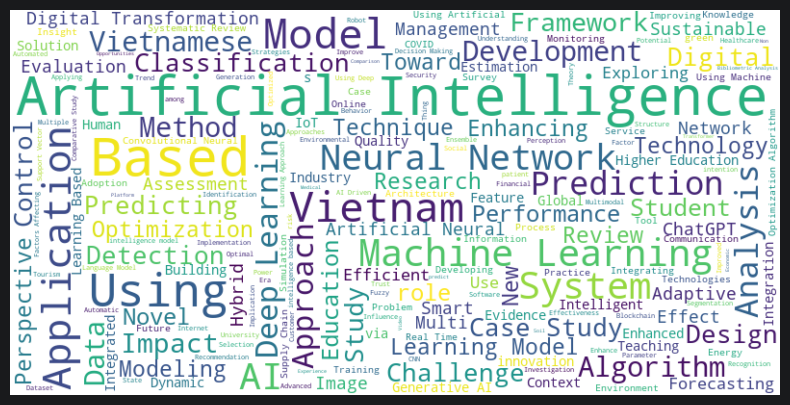

In [10]:
def plot_wordcloud(df):
    text = ' '.join(str(title) for title in df['Title'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

plot_wordcloud(df_oa)